In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from keras.utils import set_random_seed

set_random_seed(42)
np.random.seed(42)

print("Библиотеки импортированы, seed зафиксирован.")

Библиотеки импортированы, seed зафиксирован.


In [3]:
# Определение констант
A = -5                     # начало интервала
B = 2                      # конец интервала
TOTAL_COUNT = 1000         # общее количество интервалов разбиения
LEARNING_SAMPLE_SIZE = 200 # размер обучающей выборки
EPOCH_COUNT = 200          # максимальное количество эпох
NEURON_COUNT = 20          # количество нейронов в скрытых слоях

print(f"Интервал: [{A}, {B}]")
print(f"Всего точек: {TOTAL_COUNT+1}")
print(f"Размер обучающей выборки: {LEARNING_SAMPLE_SIZE}")

Интервал: [-5, 2]
Всего точек: 1001
Размер обучающей выборки: 200


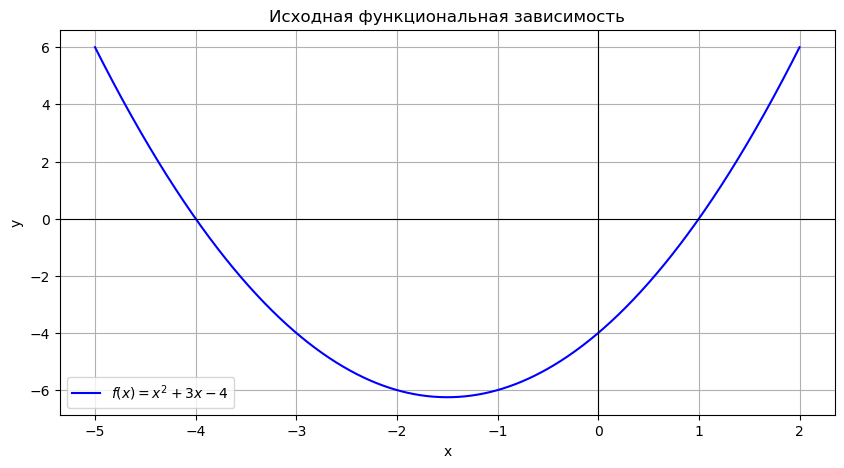

Размер x: (1001,), y: (1001,)


In [4]:
# Создание выборки и построение графика исходной функции

# Равномерное разбиение интервала
x = np.array([A + (B - A) * i / TOTAL_COUNT for i in range(TOTAL_COUNT + 1)])

# Исходная функция
def f(x):
    return x**2 + 3*x - 4

y = f(x)

# График
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='$f(x)=x^2+3x-4$', color='blue')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Исходная функциональная зависимость')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(f"Размер x: {x.shape}, y: {y.shape}")

In [6]:
# Разбиение на обучающую и тестовую выборки

# Разделение: test_size = 1 - LEARNING_SAMPLE_SIZE/TOTAL_COUNT
test_size = 1 - LEARNING_SAMPLE_SIZE / TOTAL_COUNT
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)

print(f"Обучающая выборка: x_train {x_train.shape}, y_train {y_train.shape}")
print(f"Тестовая выборка: x_test {x_test.shape}, y_test {y_test.shape}")

Обучающая выборка: x_train (200,), y_train (200,)
Тестовая выборка: x_test (801,), y_test (801,)


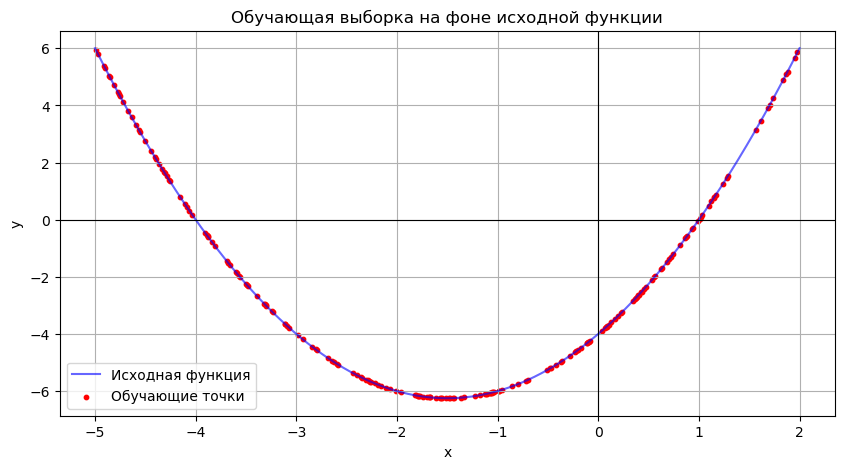

In [8]:
# Визуализация обучающей выборки 

# Сортировка для красивого отображения
sorted_indices = np.argsort(x_train)
x_train_sorted = x_train[sorted_indices]
y_train_sorted = y_train[sorted_indices]

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Исходная функция', color='blue', alpha=0.6)
plt.scatter(x_train_sorted, y_train_sorted, label='Обучающие точки', color='red', s=10)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Обучающая выборка на фоне исходной функции')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Нормализация данных

# Вычисляем среднее и стандартное отклонение по обучающей выборке
x_mean = x_train.mean(axis=0)
x_std = x_train.std(axis=0)

print(f"Среднее x_train: {x_mean:.6f}")
print(f"Ст. отклонение x_train: {x_std:.6f}")

# Нормализация
x_train_norm = (x_train - x_mean) / x_std
x_test_norm = (x_test - x_mean) / x_std

# Проверка
print(f"После нормализации: среднее = {x_train_norm.mean():.10f}, ст. откл. = {x_train_norm.std():.6f}")

Среднее x_train: -1.566710
Ст. отклонение x_train: 1.988298
После нормализации: среднее = -0.0000000000, ст. откл. = 1.000000


In [10]:
# Создание и обучение модели (без шума)

# Архитектура сети
model = Sequential()
model.add(Input(shape=(1,)))  # вход: одно число (x)
model.add(Dense(NEURON_COUNT, activation='relu')) # скрытый слой 20 нейронов
model.add(Dense(NEURON_COUNT, activation='relu')) # ещё один скрытый слой 20 нейронов
model.add(Dense(1))   # выход: одно число (прогноз y)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Обучение
history = model.fit(
    x_train_norm, y_train,
    batch_size=20,
    epochs=EPOCH_COUNT,
    verbose=1,
    validation_data=(x_test_norm, y_test)
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 20)                  │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 18.0253 - mae: 3.7620 - val_loss: 17.9070 - val_mae: 3.7791
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 17.7894 - mae: 3.7349 - val_loss: 17.7533 - val_mae: 3.7644
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 17.5728 - mae: 3.7106 - val_loss: 17.5879 - val_mae: 3.7482
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 17.3539 - mae: 3.6865 - val_loss: 17.3973 - val_mae: 3.7291
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 17.1072 - mae: 3.6600 - val_loss: 17.1794 - val_mae: 3.7062
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 16.8527 - mae: 3.6323 - val_loss: 16.9638 - val_mae: 3.6840
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 16.5629 - mae: 3.6002 - val_loss: 16.7132 - val_mae: 3.6579
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 16.2310 - mae: 3.5633 - val_loss: 16.4119 - val_mae: 3.6260
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

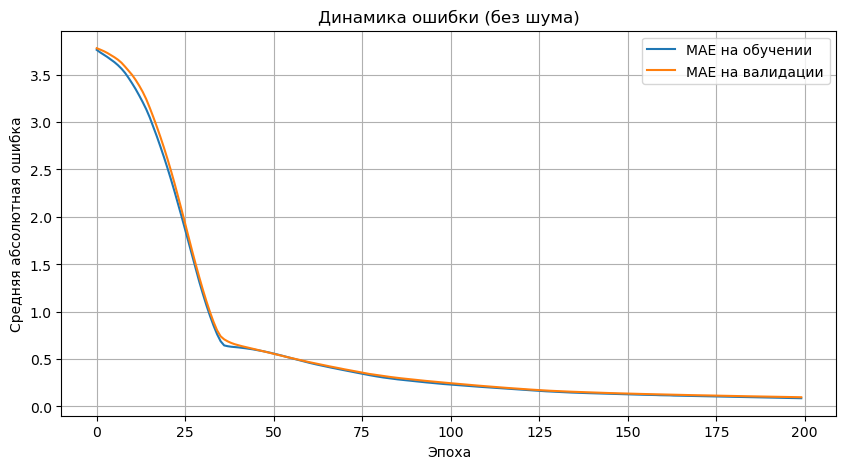

На тестовой выборке (без шума):
  Среднеквадратичная ошибка (MSE): 0.016886
  Средняя абсолютная ошибка (MAE): 0.097693
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


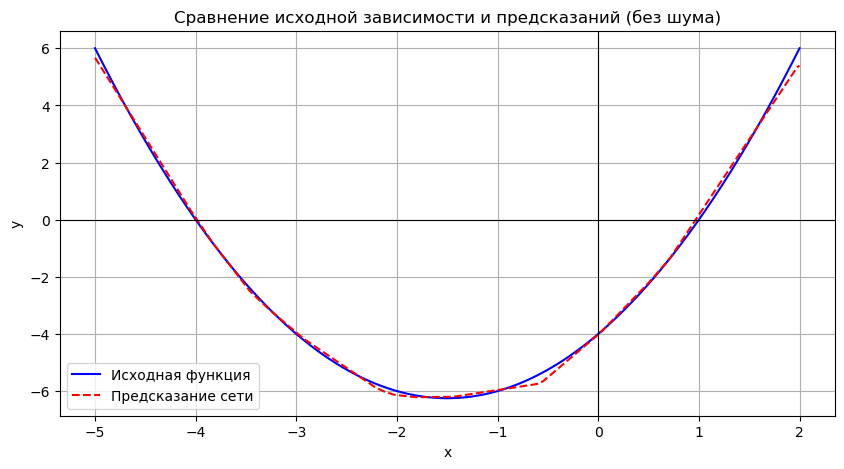

In [11]:
# Оценка точности и визуализация работы сети (без шума)

# График ошибок
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='MAE на обучении')
plt.plot(history.history['val_mae'], label='MAE на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Средняя абсолютная ошибка')
plt.title('Динамика ошибки (без шума)')
plt.legend()
plt.grid(True)
plt.show()

# Оценка на тесте
mse, mae = model.evaluate(x_test_norm, y_test, verbose=0)
print(f"На тестовой выборке (без шума):")
print(f"  Среднеквадратичная ошибка (MSE): {mse:.6f}")
print(f"  Средняя абсолютная ошибка (MAE): {mae:.6f}")

# Предсказание на всей области
x_norm_full = (x - x_mean) / x_std
y_pred = model.predict(x_norm_full).flatten()

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Исходная функция', color='blue')
plt.plot(x, y_pred, label='Предсказание сети', color='red', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Сравнение исходной зависимости и предсказаний (без шума)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Шум для обучения: Uniform[0.9, 1.6]
Шум для теста:   Uniform[0.752513, 1.247487]


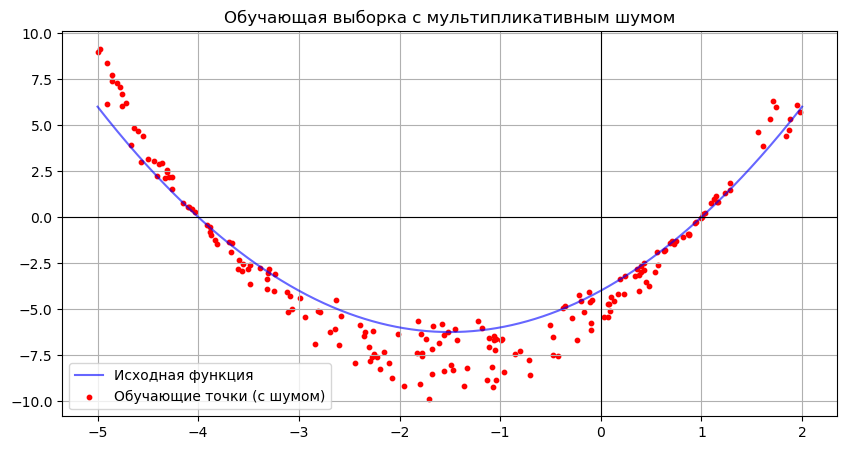

In [12]:
# Добавление стохастической компоненты (мультипликативный шум)

# Параметры шума для обучающей выборки
train_noise_low = 0.9
train_noise_high = 1.6

# Параметры для тестовой выборки (несмещённый, дисперсия в 2 раза меньше)
# Дисперсия исходного: var_orig = (0.7)^2/12 = 0.49/12 ≈ 0.0408333
# Нужная дисперсия: var_new = var_orig / 2 ≈ 0.02041667
# Для равномерного распределения: (b-a)^2/12 = var_new => b-a = sqrt(12*var_new) = sqrt(0.245) ≈ 0.4949747
# При среднем = 1 получаем: a = 1 - (b-a)/2, b = 1 + (b-a)/2
half_range = np.sqrt(0.245) / 2   # ≈ 0.247487
test_noise_low = 1 - half_range
test_noise_high = 1 + half_range

print(f"Шум для обучения: Uniform[{train_noise_low}, {train_noise_high}]")
print(f"Шум для теста:   Uniform[{test_noise_low:.6f}, {test_noise_high:.6f}]")

# Генерация шума и применение
np.random.seed(42)
noise_train = np.random.uniform(train_noise_low, train_noise_high, size=y_train.shape)
noise_test  = np.random.uniform(test_noise_low, test_noise_high, size=y_test.shape)

y_train_noisy = y_train * noise_train
y_test_noisy  = y_test * noise_test

# Визуализация зашумлённой обучающей выборки
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Исходная функция', color='blue', alpha=0.6)
plt.scatter(x_train, y_train_noisy, label='Обучающие точки (с шумом)', color='red', s=10)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Обучающая выборка с мультипликативным шумом')
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 28.1017 - mae: 4.6471 - val_loss: 18.0247 - val_mae: 3.7565
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 27.8618 - mae: 4.6250 - val_loss: 17.8825 - val_mae: 3.7431
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 27.6084 - mae: 4.6025 - val_loss: 17.6879 - val_mae: 3.7238
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 27.2990 - mae: 4.5746 - val_loss: 17.4666 - val_mae: 3.7015
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 26.9639 - mae: 4.5444 - val_loss: 17.2469 - val_mae: 3.6792
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 26.6230 - mae: 4.5138 - val_loss: 17.0319 - val_mae: 3.6572
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 26.2575 - mae: 4.4805 - val_loss: 16.7991 - val_mae: 3.6328
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 25.8586 - mae: 4.4432 - val_loss: 16.5464 - val_mae: 3.6058
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

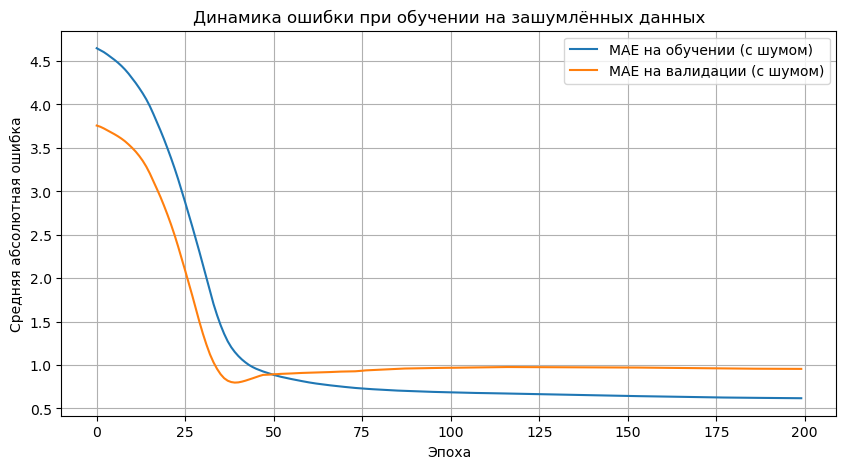

На тестовой выборке (с шумом, без Early Stopping):
  MSE: 1.492141, MAE: 0.954394
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


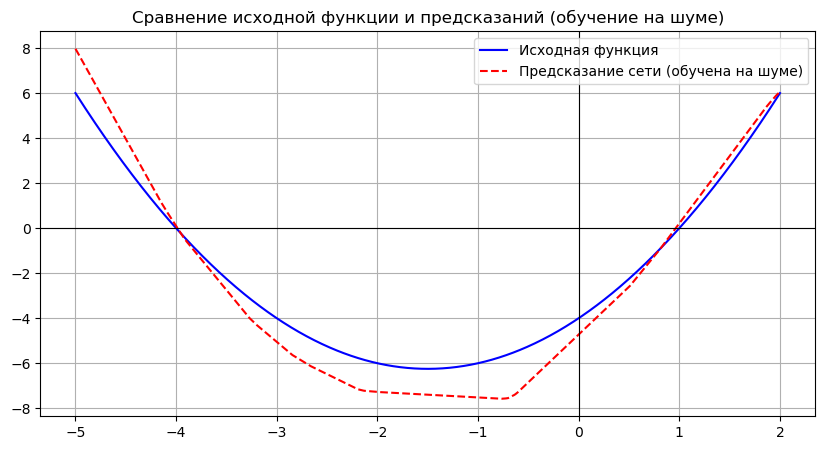

In [13]:
# Обучение модели на зашумлённых данных (без Early Stopping)

# Создаём новую модель (та же архитектура)
model_noisy = Sequential()
model_noisy.add(Input(shape=(1,)))
model_noisy.add(Dense(NEURON_COUNT, activation='relu'))
model_noisy.add(Dense(NEURON_COUNT, activation='relu'))
model_noisy.add(Dense(1))
model_noisy.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Обучение
history_noisy = model_noisy.fit(
    x_train_norm, y_train_noisy,
    batch_size=20,
    epochs=EPOCH_COUNT,
    verbose=1,
    validation_data=(x_test_norm, y_test_noisy)
)

# График ошибок
plt.figure(figsize=(10, 5))
plt.plot(history_noisy.history['mae'], label='MAE на обучении (с шумом)')
plt.plot(history_noisy.history['val_mae'], label='MAE на валидации (с шумом)')
plt.xlabel('Эпоха')
plt.ylabel('Средняя абсолютная ошибка')
plt.title('Динамика ошибки при обучении на зашумлённых данных')
plt.legend()
plt.grid(True)
plt.show()

# Оценка на тесте
mse_n, mae_n = model_noisy.evaluate(x_test_norm, y_test_noisy, verbose=0)
print(f"На тестовой выборке (с шумом, без Early Stopping):")
print(f"  MSE: {mse_n:.6f}, MAE: {mae_n:.6f}")

# Предсказания на всей области
y_pred_noisy = model_noisy.predict(x_norm_full).flatten()

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Исходная функция', color='blue')
plt.plot(x, y_pred_noisy, label='Предсказание сети (обучена на шуме)', color='red', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Сравнение исходной функции и предсказаний (обучение на шуме)')
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 28.3709 - mae: 4.6455 - val_loss: 18.1037 - val_mae: 3.7662
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 28.0699 - mae: 4.6187 - val_loss: 17.9237 - val_mae: 3.7481
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 27.7471 - mae: 4.5893 - val_loss: 17.7416 - val_mae: 3.7295
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 27.4051 - mae: 4.5571 - val_loss: 17.5610 - val_mae: 3.7110
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 27.0422 - mae: 4.5222 - val_loss: 17.3640 - val_mae: 3.6907
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 26.6507 - mae: 4.4858 - val_loss: 17.1537 - val_mae: 3.6681
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 26.2274 - mae: 4.4476 - val_loss: 16.9146 - val_mae: 3.6420
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 25.7586 - mae: 4.4046 - val_loss: 16.6428 - val_mae: 3.6099
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

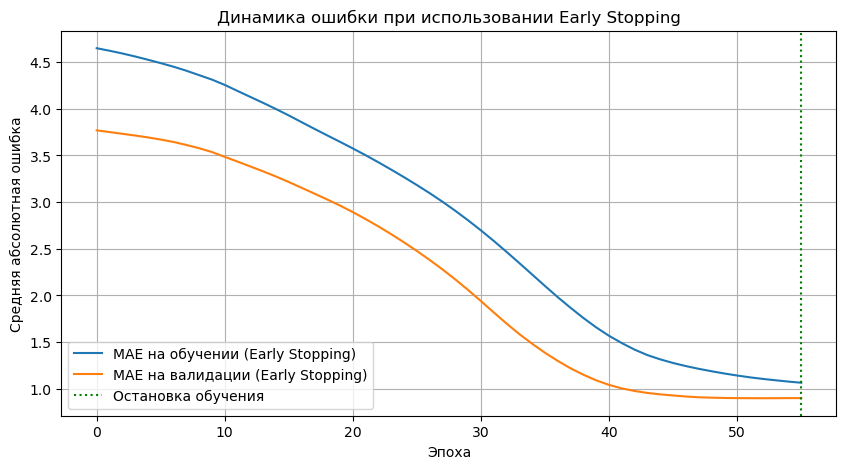

На тестовой выборке (с шумом, Early Stopping):
  MSE: 1.578347, MAE: 0.899156
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


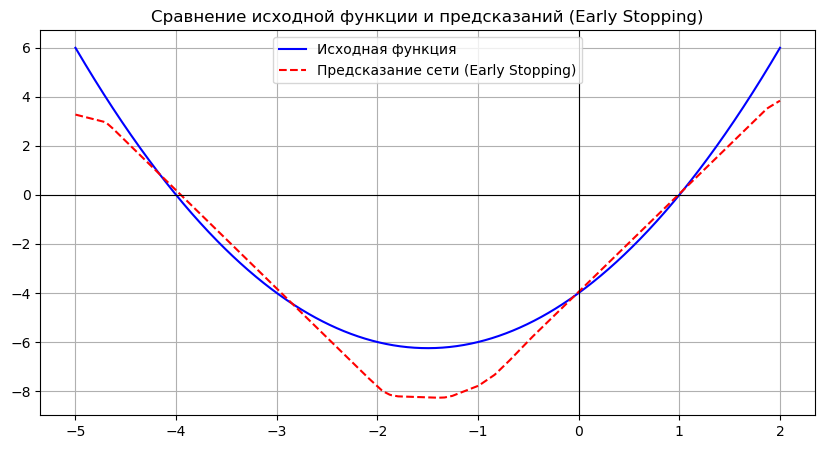

In [15]:
# Обучение с использованием EarlyStopping для борьбы с переобучением

# Создаём новую модель
model_early = Sequential()
model_early.add(Input(shape=(1,)))
model_early.add(Dense(NEURON_COUNT, activation='relu'))
model_early.add(Dense(NEURON_COUNT, activation='relu'))
model_early.add(Dense(1))
model_early.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Callback ранней остановки: следим за val_mae, останавливаем, если не улучшается 3 эпохи подряд
early_stop = EarlyStopping(monitor='val_mae', patience=3, restore_best_weights=True, verbose=1)
# если в течение 3 эпох val_mae не уменьшилась (или даже выросла), обучение останавливается

history_early = model_early.fit(
    x_train_norm, y_train_noisy,
    batch_size=20,
    epochs=EPOCH_COUNT,
    verbose=1,
    validation_data=(x_test_norm, y_test_noisy),
    callbacks=[early_stop]
)

print(f"Обучение остановлено на эпохе {len(history_early.history['mae'])}")

# График ошибок
plt.figure(figsize=(10, 5))
plt.plot(history_early.history['mae'], label='MAE на обучении (Early Stopping)')
plt.plot(history_early.history['val_mae'], label='MAE на валидации (Early Stopping)')
plt.axvline(x=len(history_early.history['mae'])-1, color='green', linestyle=':', label='Остановка обучения')
plt.xlabel('Эпоха')
plt.ylabel('Средняя абсолютная ошибка')
plt.title('Динамика ошибки при использовании Early Stopping')
plt.legend()
plt.grid(True)
plt.show()

# Оценка на тесте
mse_early, mae_early = model_early.evaluate(x_test_norm, y_test_noisy, verbose=0)
print(f"На тестовой выборке (с шумом, Early Stopping):")
print(f"  MSE: {mse_early:.6f}, MAE: {mae_early:.6f}")

# Предсказания
y_pred_early = model_early.predict(x_norm_full).flatten()

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Исходная функция', color='blue')
plt.plot(x, y_pred_early, label='Предсказание сети (Early Stopping)', color='red', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Сравнение исходной функции и предсказаний (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print("="*50)
print("Сравнение качества на тестовой выборке (с шумом):")
print(f"Без Early Stopping:  MAE = {mae_n:.6f}")
print(f"С Early Stopping:    MAE = {mae_early:.6f}")
print(f"Улучшение:           {((mae_n - mae_early)/mae_n)*100:.2f}%")
print("="*50)

Сравнение качества на тестовой выборке (с шумом):
Без Early Stopping:  MAE = 0.954394
С Early Stopping:    MAE = 0.899156
Улучшение:           5.79%


# ВЫВОД
На основе проведённых экспериментов с регрессионной зависимостью \( f(x)=x^2+3x-4 \) на интервале \([-5;2]\) можно сделать следующие выводы:

1. **В отсутствие шума** нейронная сеть с двумя скрытыми слоями по 20 нейронов успешно аппроксимирует квадратичную функцию.  
   - Средняя абсолютная ошибка (MAE) на тестовой выборке составила **0.098**, среднеквадратичная ошибка (MSE) – **0.017**.  
   - Визуально предсказанные значения практически совпадают с истинной функцией, что подтверждает способность многослойного персептрона к точной регрессии при чистом сигнале.

2. **Добавление мультипликативного шума** (равномерное распределение) к обучающей выборке привело к типичной проблеме **переобучения**:  
   - После определённой эпохи ошибка на валидационной выборке перестала снижаться и начала расти, в то время как ошибка на обучении продолжала уменьшаться.  
   - Качество предсказаний резко ухудшилось: MAE выросла до **0.954**, что почти в 10 раз хуже, чем в случае без шума.  
   - График предсказаний показывает, что сеть «выучила» шумовые выбросы, а не истинную закономерность.

3. **Применение механизма Early Stopping** (с мониторингом `val_mae` и терпением 3 эпохи) позволило частично компенсировать переобучение:  
   - Обучение было остановлено досрочно (около 50 эпох), что предотвратило дальнейшее ухудшение обобщающей способности.  
   - Значение MAE на тестовой выборке снизилось до **0.899**, что на **5.8% лучше**, чем при полном обучении без ранней остановки.  
   - Визуально предсказания стали заметно ближе к истинной функции, хотя и остались более «сглаженными» из-за присутствия шума.

### Итоговое заключение

- Нейронные сети эффективно восстанавливают регрессионные зависимости при отсутствии помех.  
- Зашумлённые данные (особенно с мультипликативным шумом, имеющим разные распределения на обучении и тесте) провоцируют переобучение, снижая способность сети к обобщению.  
- Early Stopping является простым и действенным методом борьбы с переобучением: он улучшает итоговую точность, но не может полностью устранить негативное влияние шума, если его уровень высок.  
- Для дальнейшего повышения качества работы на зашумлённых данных рекомендуется применять дополнительные методы регуляризации (L1/L2, Dropout) или увеличивать объём обучающей выборки.